# Beryllium in water
Simulations were run at 350 K for 50 ps.

The system contained 112 water molecules and one Be2+/BeCl2 unit, resulting in a 1 M concentration.

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os


import utils.helper_funcs as hf
#import utils.thermo_funcs as tf


from ase.io import read

data_path = '../data'

MP0_paths = {
    'Be$^{2+}$(aq)':'/MACE-MP-0/112_water/Be2+/',
    'BeCl$_2$(aq)':'/MACE-MP-0/112_water/BeCl2/',
}
POLAR_paths = {
    'Be$^{2+}$(aq)':'/MACE-POLAR-1-M/112_water_Be/Be2+/',
    'BeCl$_2$(aq)':'/MACE-POLAR-1-M/112_water_Be/BeCl2/',
}

plt.rcParams.update({'font.size': 14})

# Be-O Structure

## MACE-MP-0
- Beryllium cooridnation to neghbouring water molecules is similar between Be2+(aq) and BeCl2(aq)

In [106]:
MP0_rdf_data = hf.load_data(MP0_paths, root_dir=data_path, fname='travis/rdf_Be_O_[Be1r_O1o].csv')

Loading data for 'Be$^{2+}$(aq)' from '../data/MACE-MP-0/112_water/Be2+/travis/rdf_Be_O_[Be1r_O1o].csv'
Loading data for 'BeCl$_2$(aq)' from '../data/MACE-MP-0/112_water/BeCl2/travis/rdf_Be_O_[Be1r_O1o].csv'


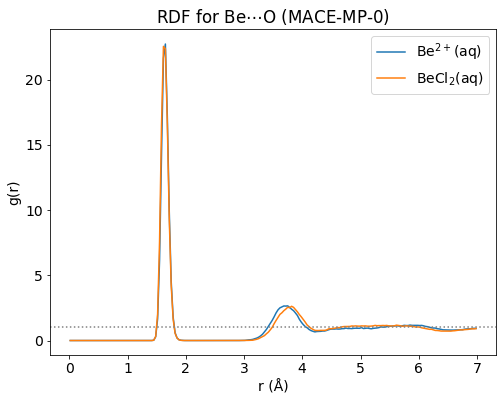

In [107]:
fig, ax = plt.subplots(figsize=(8, 6))
for key, data in MP0_rdf_data.items():
    ax.plot(data['# Distance / pm']/100, data['  g(r)'], label=key)
    rmax = data['# Distance / pm'].max()/100
ax.set_title(f'RDF for Be$\\cdots$O (MACE-MP-0)')
ax.set_xlabel('r (Å)')
ax.set_ylabel('g(r)')
ax.axhline(1, 0, rmax, color='gray', linestyle=':')
ax.legend()
plt.show()

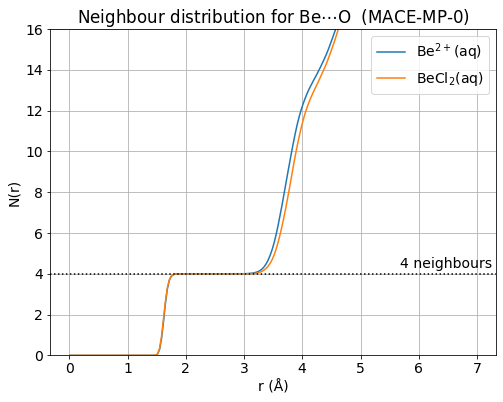

In [108]:
fig, ax = plt.subplots(figsize=(8, 6))
for key, data in MP0_rdf_data.items():
    ax.plot(data['# Distance / pm']/100, data['  Integral'], label=key)

y = 4
ax.axhline(4, 0, color='black', linestyle=':')
plt.annotate(
    f"{y} neighbours",
    xy=(1-0.01, y+0.5),
    xycoords=('axes fraction', 'data'),
    ha='right',
    va='center'
)

ax.set_title(f'Neighbour distribution for Be$\\cdots$O  (MACE-MP-0)')
ax.set_xlabel('r (Å)')
ax.set_ylabel('N(r)')
ax.set_ylim(0, 16)
ax.grid()
ax.legend()
plt.show()

## MACE-POLAR-1-M
SIMULATIONS ARE NOT YET FINISHED
- Beryllium cooridnation to neghbouring water molecules is similar between Be2+(aq) and BeCl2(aq)

In [109]:
POLAR_rdf_data = hf.load_data(POLAR_paths, root_dir=data_path, fname='travis/rdf_Be_O_[Be1r_O1o].csv')

Loading data for 'Be$^{2+}$(aq)' from '../data/MACE-POLAR-1-M/112_water_Be/Be2+/travis/rdf_Be_O_[Be1r_O1o].csv'
Loading data for 'BeCl$_2$(aq)' from '../data/MACE-POLAR-1-M/112_water_Be/BeCl2/travis/rdf_Be_O_[Be1r_O1o].csv'


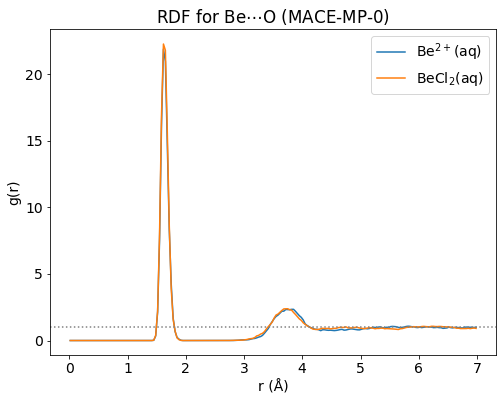

In [110]:
fig, ax = plt.subplots(figsize=(8, 6))
for key, data in POLAR_rdf_data.items():
    ax.plot(data['# Distance / pm']/100, data['  g(r)'], label=key)
    rmax = data['# Distance / pm'].max()/100
ax.set_title(f'RDF for Be$\\cdots$O (MACE-MP-0)')
ax.set_xlabel('r (Å)')
ax.set_ylabel('g(r)')
ax.axhline(1, 0, rmax, color='gray', linestyle=':')
ax.legend()
plt.show()

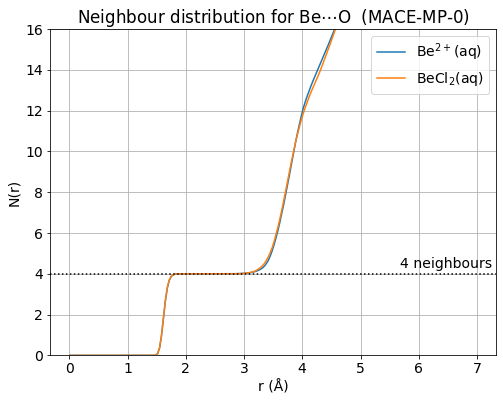

In [111]:
fig, ax = plt.subplots(figsize=(8, 6))
for key, data in POLAR_rdf_data.items():
    ax.plot(data['# Distance / pm']/100, data['  Integral'], label=key)

y = 4
ax.axhline(4, 0, color='black', linestyle=':')
plt.annotate(
    f"{y} neighbours",
    xy=(1-0.01, y+0.5),
    xycoords=('axes fraction', 'data'),
    ha='right',
    va='center'
)

ax.set_title(f'Neighbour distribution for Be$\\cdots$O  (MACE-MP-0)')
ax.set_xlabel('r (Å)')
ax.set_ylabel('N(r)')
ax.set_ylim(0, 16)
ax.grid()
ax.legend()
plt.show()

## MACE-POLAR-1-M vs MACE-MP-0
- Beryllium cooridnation to neghbouring water molecules is similar between MACE-MP-0 and MACE-POLAR-1-M

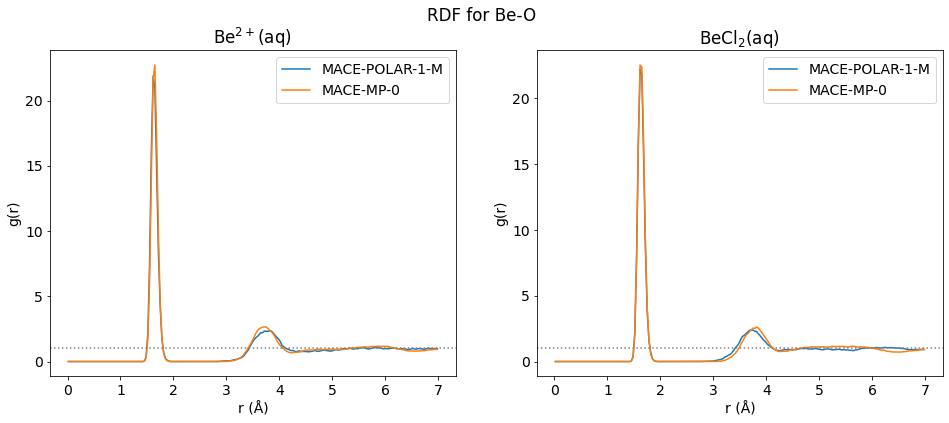

In [112]:
fig, axs = plt.subplots(1, 2, figsize=(8*2, 6))
fig.suptitle(f'RDF for Be-O')
for i, key in enumerate(POLAR_rdf_data):
    r = POLAR_rdf_data[key]['# Distance / pm']/100
    axs[i].set_title(key)
    axs[i].set_xlabel('r (Å)')
    axs[i].set_ylabel('g(r)')

    axs[i].plot(r, POLAR_rdf_data[key]['  g(r)'], label='MACE-POLAR-1-M')
    axs[i].plot(r, MP0_rdf_data[key]['  g(r)'], label='MACE-MP-0')
    rmax = POLAR_rdf_data[key]['# Distance / pm'].max()/100

    axs[i].legend()
    axs[i].axhline(1, 0, rmax, color='gray', linestyle=':')
plt.show()

Be$^{2+}$(aq)
BeCl$_2$(aq)


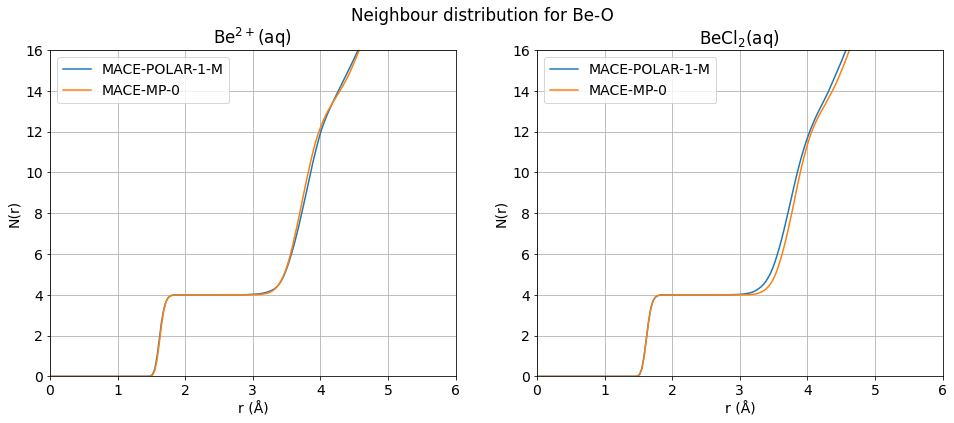

In [113]:
fig, axs = plt.subplots(1, 2, figsize=(8*2, 6))
fig.suptitle(f'Neighbour distribution for Be-O')
for i, key in enumerate(POLAR_rdf_data):
    print(key)
    r = POLAR_rdf_data[key]['# Distance / pm']/100
    axs[i].set_title(key)
    axs[i].set_xlabel('r (Å)')
    axs[i].set_ylabel('N(r)')
    axs[i].set_ylim(0, 16)
    axs[i].set_xlim(0, 6)
    
    axs[i].grid()

    axs[i].plot(r, POLAR_rdf_data[key]['  Integral'], label='MACE-POLAR-1-M')
    axs[i].plot(r, MP0_rdf_data[key]['  Integral'], label='MACE-MP-0')
    rmax = POLAR_rdf_data[key]['# Distance / pm'].max()/100

    axs[i].legend()
plt.show()

# Be[O]-O structure
- Oxygens (O) attached to the beryllium coordinate with oxygens (O) in neigbouring water molecules (H2O)
- There are slight differences between Be in Be2+(aq) and in BeCl2(aq)
- The polarisation of these O-O bonds are similar between MACE-MP-0 and MACE-POLAR-1-M
    - The local MACE-MP-0 seem to capture the oxidation state of Be2+

In [114]:
MP0_OO_rdf_data = hf.load_data(MP0_paths, root_dir=data_path, fname='travis/rdf_BeH8O4_H2O_[Or_Oo].csv')
POLAR_OO_rdf_data = hf.load_data(POLAR_paths, root_dir=data_path, fname='travis/rdf_BeH8O4_H2O_[Or_Oo].csv')

Loading data for 'Be$^{2+}$(aq)' from '../data/MACE-MP-0/112_water/Be2+/travis/rdf_BeH8O4_H2O_[Or_Oo].csv'
Loading data for 'BeCl$_2$(aq)' from '../data/MACE-MP-0/112_water/BeCl2/travis/rdf_BeH8O4_H2O_[Or_Oo].csv'
Loading data for 'Be$^{2+}$(aq)' from '../data/MACE-POLAR-1-M/112_water_Be/Be2+/travis/rdf_BeH8O4_H2O_[Or_Oo].csv'
Loading data for 'BeCl$_2$(aq)' from '../data/MACE-POLAR-1-M/112_water_Be/BeCl2/travis/rdf_BeH8O4_H2O_[Or_Oo].csv'


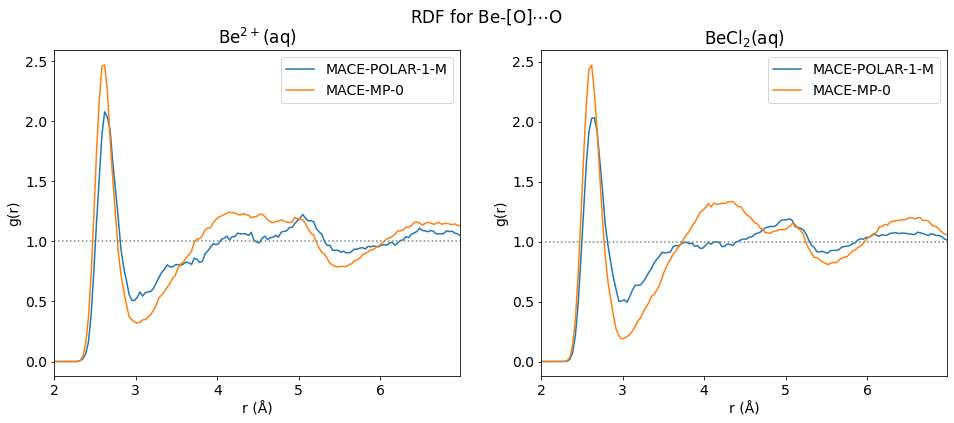

In [115]:
fig, axs = plt.subplots(1, 2, figsize=(8*2, 6))
fig.suptitle(f'RDF for Be-[O]$\\cdots$O')
for i, key in enumerate(POLAR_OO_rdf_data):
    r = POLAR_OO_rdf_data[key]['# Distance / pm']/100
    axs[i].set_title(key)
    axs[i].set_xlabel('r (Å)')
    axs[i].set_ylabel('g(r)')
    axs[i].set_xlim(2, max(r))


    axs[i].plot(r, POLAR_OO_rdf_data[key]['  g(r)'], label='MACE-POLAR-1-M')
    axs[i].plot(r, MP0_OO_rdf_data[key]['  g(r)'], label='MACE-MP-0')
    rmax = POLAR_OO_rdf_data[key]['# Distance / pm'].max()/100

    axs[i].legend()
    axs[i].axhline(1, 0, rmax, color='gray', linestyle=':')
plt.show()

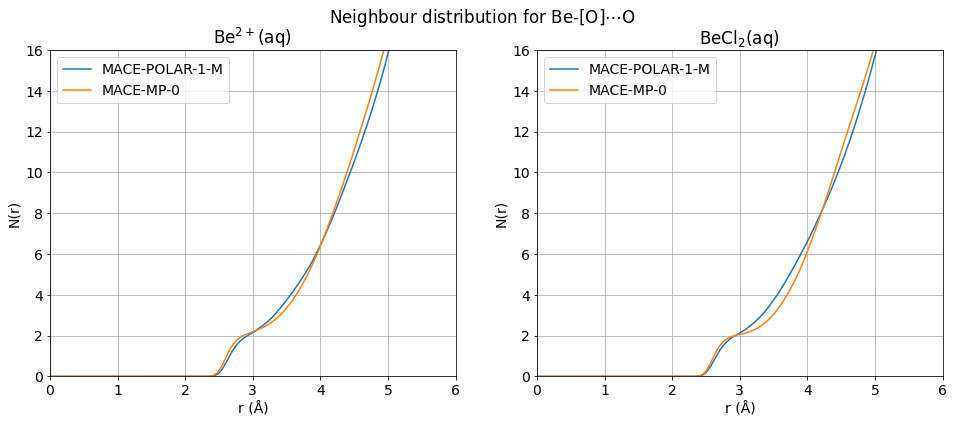

In [116]:
fig, axs = plt.subplots(1, 2, figsize=(8*2, 6))
fig.suptitle(f'Neighbour distribution for Be-[O]$\\cdots$O')
for i, key in enumerate(POLAR_OO_rdf_data):
    r = POLAR_OO_rdf_data[key]['# Distance / pm']/100
    axs[i].set_title(key)
    axs[i].set_xlabel('r (Å)')
    axs[i].set_ylabel('N(r)')
    axs[i].set_ylim(0, 16)
    axs[i].set_xlim(0, 6)

    axs[i].grid()

    axs[i].plot(r, POLAR_OO_rdf_data[key]['  Integral'], label='MACE-POLAR-1-M')
    axs[i].plot(r, MP0_OO_rdf_data[key]['  Integral'], label='MACE-MP-0')
    rmax = POLAR_OO_rdf_data[key]['# Distance / pm'].max()/100

    axs[i].legend()
plt.show()

# H2[O]-[O]H2 structure
- MACE-POLAR-1-M better captures the structure of water associated with elevated temperatures
- MACE-MP-0 is over structured, especially given the temperature
    - This type of structuring is prevalent in PBE (without dispersion, here we used D3)
    - Might also have to do with highly ordered structures being prevalent in the training data (MPTrj)
    - *This could mean that the polarisation that seemed to be captured in the Be-[O]-[O] plot above is an artefact (polarisation comes from ice-like coordination rather than beiong induced by the beryllium)*

In [117]:
MP0_H2OOH2_rdf_data = hf.load_data(MP0_paths, root_dir=data_path, fname='travis/rdf_H2O_H2O_[Or_Oo].csv')
POLAR_H2OOH2_rdf_data = hf.load_data(POLAR_paths, root_dir=data_path, fname='travis/rdf_H2O_H2O_[Or_Oo].csv')

Loading data for 'Be$^{2+}$(aq)' from '../data/MACE-MP-0/112_water/Be2+/travis/rdf_H2O_H2O_[Or_Oo].csv'
Loading data for 'BeCl$_2$(aq)' from '../data/MACE-MP-0/112_water/BeCl2/travis/rdf_H2O_H2O_[Or_Oo].csv'
Loading data for 'Be$^{2+}$(aq)' from '../data/MACE-POLAR-1-M/112_water_Be/Be2+/travis/rdf_H2O_H2O_[Or_Oo].csv'
Loading data for 'BeCl$_2$(aq)' from '../data/MACE-POLAR-1-M/112_water_Be/BeCl2/travis/rdf_H2O_H2O_[Or_Oo].csv'


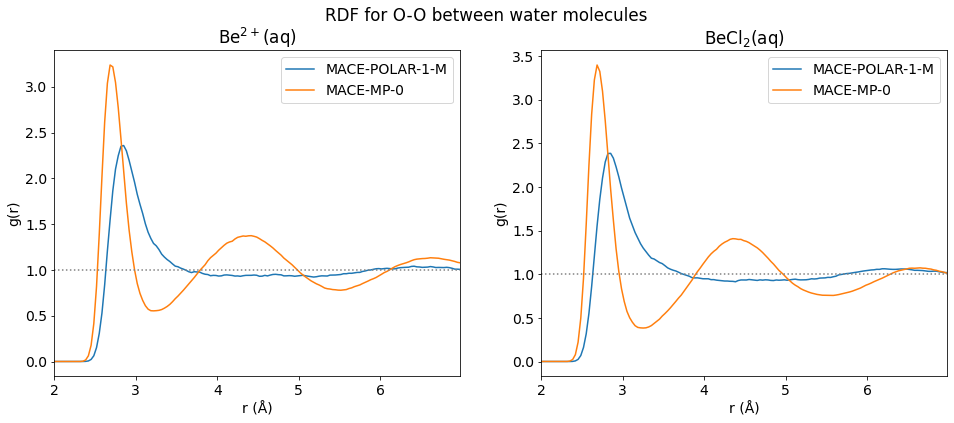

In [118]:
fig, axs = plt.subplots(1, 2, figsize=(8*2, 6))
fig.suptitle(f'RDF for O-O between water molecules')
for i, key in enumerate(POLAR_H2OOH2_rdf_data):
    r = POLAR_H2OOH2_rdf_data[key]['# Distance / pm']/100
    axs[i].set_title(key)
    axs[i].set_xlabel('r (Å)')
    axs[i].set_ylabel('g(r)')
    axs[i].set_xlim(2, max(r))

    axs[i].plot(r, POLAR_H2OOH2_rdf_data[key]['  g(r)'], label='MACE-POLAR-1-M')
    axs[i].plot(r, MP0_H2OOH2_rdf_data[key]['  g(r)'], label='MACE-MP-0')
    rmax = POLAR_H2OOH2_rdf_data[key]['# Distance / pm'].max()/100

    axs[i].legend()
    axs[i].axhline(1, 0, rmax, color='gray', linestyle=':')
plt.show()

# Be-Cl structure
- There are Be-Cl interactions present in the MACE-POLAR-1-M simulations
- The Be-Cl distance exceeds the first layer cut-off of 6 Å in the MACE-MP-0, and the interactions from the next layer are not sufficient to correlate Be to Cl
    - Long range interactions are needed to capture this
    - From this plot, we expect considerable differences in the conductivity between the two MLIPs

In [119]:
BeCl_paths = {
    'MACE-MP-0':'/MACE-MP-0/112_water/BeCl2/',
    'MACE-POLAR-1-M':'/MACE-POLAR-1-M/112_water_Be/BeCl2/',
}
BeCl_rdf_data = hf.load_data(BeCl_paths, root_dir=data_path, fname='travis/rdf_Be_Cl_[Be1r_Cl1o]_long.csv')

Loading data for 'MACE-MP-0' from '../data/MACE-MP-0/112_water/BeCl2/travis/rdf_Be_Cl_[Be1r_Cl1o]_long.csv'
Loading data for 'MACE-POLAR-1-M' from '../data/MACE-POLAR-1-M/112_water_Be/BeCl2/travis/rdf_Be_Cl_[Be1r_Cl1o]_long.csv'


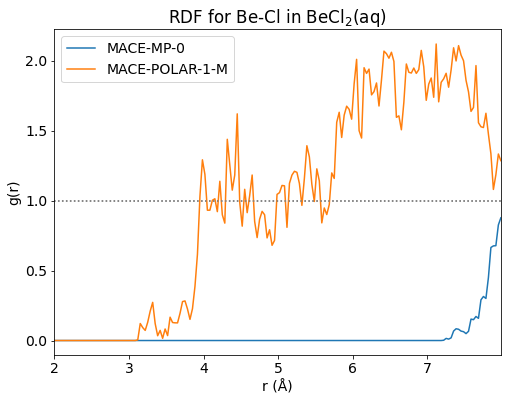

In [120]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(f'RDF for Be-Cl in BeCl$_2$(aq)')
for i, key in enumerate(BeCl_rdf_data):
    r = BeCl_rdf_data[key]['# Distance / pm']/100
    ax.set_xlabel('r (Å)')
    ax.set_ylabel('g(r)')
    ax.set_xlim(2, max(r))

    ax.plot(r, BeCl_rdf_data[key]['  g(r)'], label=key)
    rmax = BeCl_rdf_data[key]['# Distance / pm'].max()/100

    ax.legend()
    ax.axhline(1, 0, rmax, color='gray', linestyle=':')
plt.show()

# Thermodynamic properties
- Both MLIPs yield, for the most part, reasonable thermodynamic properties
- The exception being the heat capacity
    - MACE-MP-0: The Be2+(aq) and BeCl2(aq) heat capacities are around 3 and 2 times larger, respectively, than for pure water. There are also large uncertainties (CV(Be2+)=32%, CV(BeCl2)=23%)
    - MACE-POLAR-1-M: The Be2+(aq) and BeCl2(aq) heat capacities are around 2.5 times larger, than for pure water. There are also large uncertainties (CV(Be2+)=20%, CV(BeCl2)=18%)

## MACE-MP-0

In [121]:
MP0_thermo_df = hf.cached_thermo_props(
    'results/beryllium/MP0_thermo_props.json',
    MP0_paths, 
    data_path, 
    temperature=350.0, 
    correlation_times={"density": 100, "heat_capacity": 100, "compressibility": 100, "bulk_modulus": 100, "thermal_expansion": 100}, # times are given in frames, there is 5 fs between , the correlation times are typically 500 fs
    block_factor=10,
)
MP0_thermo_df

Loaded thermodynamic properties from results/beryllium/MP0_thermo_props.json


In [122]:
mu = MP0_thermo_df.data.loc[(slice(None), "Heat Capacity /kJ mol-1 K-1"), "mean"]
sigma = MP0_thermo_df.data.loc[(slice(None), "Heat Capacity /kJ mol-1 K-1"), "stderr"]
print('Uncertainties (CV) in the heat capacity:')
sigma/mu*100

Uncertainties (CV) in the heat capacity:


system         property                   
Be$^{2+}$(aq)  Heat Capacity /kJ mol-1 K-1    32.247385
BeCl$_2$(aq)   Heat Capacity /kJ mol-1 K-1    23.772639
dtype: float64

## MACE-POLAR-1-M

In [123]:
POLAR_thermo_df = hf.cached_thermo_props(
    'results/beryllium/POLAR_thermo_props.json',
    POLAR_paths, 
    data_path, 
    temperature=350.0, 
    correlation_times={"density": 100, "heat_capacity": 100, "compressibility": 100, "bulk_modulus": 100, "thermal_expansion": 100}, # times are given in frames, there is 5 fs between each, the correlation times are typically 500 fs
    block_factor=10,
)
POLAR_thermo_df

results/beryllium/POLAR_thermo_props.json not found. Computing thermodynamic properties...
Loading trajectory data...
Loading data for 'Be$^{2+}$(aq)' from '../data/MACE-POLAR-1-M/112_water_Be/Be2+/112_water_Be_polar.traj'
Loading data for 'BeCl$_2$(aq)' from '../data/MACE-POLAR-1-M/112_water_Be/BeCl2/112_water_BeCl2_polar.traj'
Finished loading trajectory data.
Computing thermodynamic properties...
Saved thermodynamic properties to results/beryllium/POLAR_thermo_props.json


In [124]:
mu = POLAR_thermo_df.data.loc[(slice(None), "Heat Capacity /kJ mol-1 K-1"), "mean"]
sigma = POLAR_thermo_df.data.loc[(slice(None), "Heat Capacity /kJ mol-1 K-1"), "stderr"]
print('Uncertainties (CV) in the heat capacity:')
sigma/mu*100

Uncertainties (CV) in the heat capacity:


system         property                   
Be$^{2+}$(aq)  Heat Capacity /kJ mol-1 K-1    19.476554
BeCl$_2$(aq)   Heat Capacity /kJ mol-1 K-1    17.990509
dtype: float64

## MACE-MP-0 vs MACE-POLAR-1-M
- Compared to MACE-POLAR-1-M, MACE-MP-0 overestimates the bulk modulus, density (slightly) and the heat capacity for the Be2+(aq) system
- The thermal expansion coefficient and compressibility are very similar


In [138]:
print('MACE-MP-0 subtracted from MACE-POLAR-1-M:')
POLAR_thermo_df.data[["mean"]]-MP0_thermo_df.data[["mean"]]


MACE-MP-0 subtracted from MACE-POLAR-1-M:


mean
system        property                                 
Be$^{2+}$(aq) Bulk Modulus /GPa           -2.875006e+00
              Compressibility /Pa-1        1.542049e-10
              Density /g cm-3             -1.282755e-02
              Heat Capacity /kJ mol-1 K-1 -3.258461e+00
              Thermal Expansion /K-1       2.509651e-04
BeCl$_2$(aq)  Bulk Modulus /GPa           -2.774828e+00
              Compressibility /Pa-1        7.069705e-11
              Density /g cm-3              4.560517e-02
              Heat Capacity /kJ mol-1 K-1  1.321164e+00
              Thermal Expansion /K-1       6.964758e-05